

# Notebook – Intergenerational differences in exposure to extreme events

Objectives of the exercise:
-	Understand the nature of the results described in the abovementioned publications and the underlying methodology
-	Reproduce the results
-	Adjust the available code and produce new results based on this methodology, using new data and tailored to the South Asian context

Disclaimer: the code used for this exercise is still work in progress, scientific publications using it are currently in preparation and it is thus subject to change. Therefore, please do not share the scripts and notebook, and always consult with the authors of the exercise before sharing results or including them in external communications or scientific publications.

See the 1-pager document provided with this exercise for more information.

-----------

The solutions to the instructions included in this notebook are available in climakidws_india_dkrz_solutions.ipynb

-----------

Before running this notebook, take a look at the _settings.py file. This python script defines paths to data files and directories used in this notebook.
It also defines some configurations, resolutions and options to use when running the script.
Adjust the paths as needed before proceeding with the rest of the notebook.

In [1]:
# Let's start by importing all necessary packages and functions defined in this folder.

import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('../..') # location of dem4cli package
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from dem4cli import * # to call fxns directly


In [2]:
# This code can be run using different configurations, different resolutions and different options. Which ones are we using?

flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [3]:
# We'll run the analysis on a domain that can be specified here: Lat S, Lat N, Lon W, Lon E.

bbox_indiaws = [ 2.00, 40.00, 66.00, 100.00 ]

## 1) Shapefile preprocessing

For the purpose of this exercise we'll use another shapefile for country boundaries than the one used by default in this code. We first need to pre-process this new shapefile to make sure its format matches what's required later on in the exercise.

In [4]:
# Load new shapefile, explore it

# Shapefile with polygons to be used in this exercise
gdf_worldadmin = gpd.read_file(os.path.join(data_dir, 'country-masks/shapefiles/WorldAdmin/WordlAdminV3.shp'))


In [5]:
# Instructions:
# Which information is available in the shapefile? Can you show the titles of the columns corresponding to each if the variables stored in the shapefile?
# Which column contains information on the ISO codes of the countries? 


In [6]:
# Pre-process the new shapefile to make sure its format matches what's required later on in the exercise.

# Drop rows where GMI_CNTRY is missing or empty 
gdf_worldadmin = gdf_worldadmin[gdf_worldadmin["GMI_CNTRY"].notna() & (gdf_worldadmin["GMI_CNTRY"] != "")].copy()

# Rename to match the column name in the original shapefile, required to be consistent with pipeline
gdf_worldadmin = gdf_worldadmin.rename(columns={"GMI_CNTRY": "ADM0_A3"})

# Remove duplicates, keep only first occurrence of each country ---
gdf_worldadmin = gdf_worldadmin.drop_duplicates(subset="ADM0_A3", keep="first").reset_index(drop=True)

modified_shapefile = os.path.join(data_dir, 'country-masks/shapefiles/WorldAdmin/WorldAdminV3_woduplicates.shp')
gdf_worldadmin.to_file(modified_shapefile)
print(f"Updated shapefile written to: {modified_shapefile}")

Updated shapefile written to: /home/b/b383838/data_dem4cli/data/country-masks/shapefiles/WorldAdmin/WorldAdminV3_woduplicates.shp


## 2) Population preprocessing

This section take care of loading and preprocessing all demographic data required for the analysis. 
It uses a wrapper function called preprocess_all_country_data and defined in population_demographics.py.

You can have a look at how preprocess_all_country_data is defined to understand which functions it calls and what it does. 
You can also read the Methods part of Grant et al. (2025) or the Supplementary Material of Thiery et al. (2021) to understand what demographic data are used in this analysis and how they are processed for this purpose.

In [9]:
# Instructions:
# What demographic datasets are used in this analysis? Where do we source them from?
# 
# What kind of life expectancy do we use? Which processing steps are applied to these data? What is the difference between period and cohort life expectancy, and which one are we focusing on here?

# At what scale or resolution are the demographics datasets available? Which assumption is made in this analysis to obtain local results such as those shown in Fig. 1 of Grant et al. (2025)?

In [7]:
# Instructions:
# Make sure that the function below call the shapefile you have just created.
# Make sure that the path to data directories are correctly defined to be able to load the required data.

d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    bbox = bbox_indiaws,

    filepath_countrymask = incorrect_shapefile,
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask']

load_country_metadata took 0.03 s
load_unwpp_lifeexpectancy took 32.78 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 33.95 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


opening compass - ssp2


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


load_population took 0.64 s
load_countrymask took 1.15 s
preprocess_all_country_data took 68.57 s


In [10]:
# Instructions:

# Explore a dataset created by the previous function. Over which type of geographical entity have the results been aggregated?
# What list of such entities is included in the dataset?

## 3) Load stylised Global Mean Temperature trajectories
 
The results presented in Thiery et al. (2021) or Grant et al. (2025) are obtained using model simulations of the evolution of climate extreme indicators. 
These simulations were conducted as part of the ISIMIP2b project (Frieler et al., 2017), for a handful of scenarios spanning the possible future evolution of the climate. 
However Thiery et al. (2021) or Grant et al. (2025) show results for a different set of scenarios, instead defined by the evolution of Global Mean Temperature over the 21st century. 
This was done to focus on results for global warming levels commonly discussed in the policy sphere, as well as to explore impacts for increments of global warming.

This section intends to load these scenarios and plot them to facilitate their exploration.

Frieler, K., et al.: Assessing the impacts of 1.5 °C global warming – simulation protocol of the Inter-Sectoral Impact Model Intercomparison Project (ISIMIP2b), Geosci. Model Dev., 10, 4321–4345, https://doi.org/10.5194/gmd-10-4321-2017, 2017


In [11]:
# Load the Global Mean Temperature trajectories defined in Thiery et al and Grant et al.

df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

sh: getfattr: command not found


load_GMT took 8.56 s


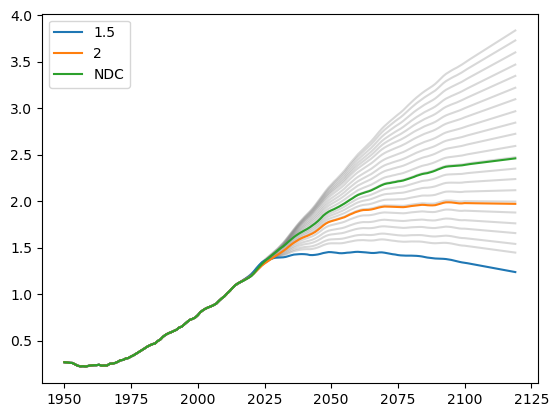

In [12]:
# Plot the obtained GMT trajectories

fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_NDC]):
    labels[i] = labels[i] 
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

In [13]:
# Instructions:

# Identify in the previous plot the equivalents of the GMT trajectories used in Thiery et al. (2021).

# What are the gray trajectories? In the dataframe containing their value, what does the column name correspond to? 


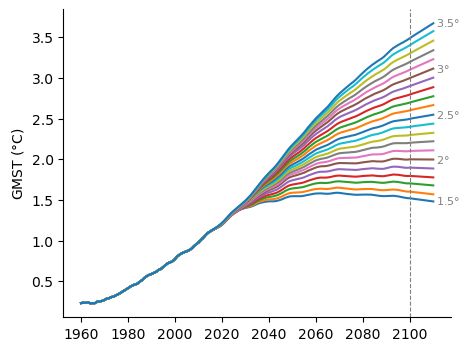

In [14]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

## 4) Load climate data and calculate GMT-mapping recipe

This framework calculates projections for climate extreme indicators for the GMT trajectories shown in the previous section. 
Those are however derived from model simulations of the evolution of such indicators, but for the scenarios used in the ISIMIP2b project.
This step is conducted using a methodology called also mapping recipe, described in the Supplementary Material of Thiery et al or the Methods section of Grant et al.


In [15]:
# Instructions:

# Read about the description for the mapping methodology.
# What scenarios are used in ISIMIP2b? How were they defined?
# In contrast, what are the scenarios used in Thiery et al. and Grant et al.?
# How are the results for the latter derived from the former? Which figures of the SM of Grant et al. illustrate this? 
# How is this approach referred to in Thiery et al.? How is the validity of this approach tested?
# Which additional criterion is applied to retain the ISIMIP simulations for which the mapping methodology can work best?

In [16]:
# This part defines which extreme event we are interested in, as well as the characteristics of the ISIMIP simulations used for the remapping: which GCMs were used to force them, which scenarios, which impact models...

# We will run the load_climate_data function with these arguments:

data_source = 'ISIMIP'
project_phase = 'ISIMIP2B'
GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS]
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
rolling_window=21
min_periods=11
max_diff_valid=.2


# One may choose among those GCMs depending on the data source:
GCMs = ['GFDL-ESM2M']  # for ISIMIP 2b indicators: ['GFDL-ESM2M', 'HadGEM2-ES', 'IPSL-CM5A-LR', 'MIROC5']
#GCMs = ['MPI-ESM1-2-HR'] # for ISIMIP3b indicators
#GCMs = ['CanESM5'].   # for ClimaKid indicators

# One may choose among those scenarios depending on the data source:
scenarios = ['rcp85'] # for ISIMIP 2b indicators: ['rcp26', 'rcp60', 'rcp85']
#scenarios = ['ssp370'] # for ISIMIP3b indicators

# One may choose among those indicators depending on the data source:
extremes = ["heatwavedarea"]  # for ISIMIP2b, choose among "heatwavedarea", "tropicalcyclonedarea", "floodedarea", "driedarea", "cropfailedarea", "burntarea"
#extremes = # for ISIMIP3b, choose among "heatwavedarea", "tropicalcyclonedarea", "floodedarea", "driedarea", "cropfailedarea", "burntarea"

# One may choose among those impact model names epending on the data source:
IMs = {f"{extremes[0]}": ['hwmid99']} # for ISIMIP2B indicators   --> check available impact models in the folder containing ISIMIP data
# IMs = {f"{extremes[0]}": ['hwmid-humidex']}  # e.g. for ISIMIP3B

In [17]:
# This part is meant to obtain the Global Mean Temperature trajectories from the bias-adjusted Global Climate Models that were used in ISIMIP.
# Those are either already available in the required format or need to be generated in this format.

if project_phase.lower() == 'isimip2b':

    # This piece of code reads GMST values from GCMs used in ISIMIP2b and stores them in a dataframe saved as csv, in the format required for the rest of the code to work.

    dir_gmst_gcms = os.path.join(data_dir, 'isimip/isimip2b/DerivedInputData/globalmeans/tas')
    simulations = ['historical', 'rcp26', 'rcp45', 'rcp60', 'rcp85']
    file_gmst_gcms = os.path.join(data_dir, 'isimip/isimip2b/gmst_gcms_ISIMIP2b.csv')

    # Initialize an empty DataFrame
    df_long = pd.DataFrame(columns=['year', 'experiment_id', 'source_id', 'tas'])

    for gcm in GCMs:
        for simul in simulations:
            # Get the file path
            file_path = glob.glob(os.path.join(dir_gmst_gcms, gcm, f'tas_*{gcm}_{simul}*fldmean.yearmean.txt'))[0]

            # Read the data
            df = pd.read_csv(file_path, delim_whitespace=True, comment='#', header=None, names=['year', 'tas'])

        # Filter for years up to 2100
        #df = df[df['year'] <= 2100]

            # Add columns for experiment_id and source_id
            df['experiment_id'] = simul
            df['source_id'] = gcm

            # Append to the long DataFrame
            df_long = pd.concat([df_long, df[['year', 'experiment_id', 'source_id', 'tas']]], ignore_index=True)

    # Sort the DataFrame
    df_long = df_long.sort_values(by=['year', 'experiment_id', 'source_id']).reset_index(drop=True)

    # Export the DataFrame to a CSV file
    df_long.to_csv(file_gmst_gcms, index=True)

    print(f"Data exported to {file_gmst_gcms}")

elif project_phase.lower() == 'isimip3b':
    # for Lange et al indicators from ISIMIP3b
    file_gmst_gcms = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')
    
    # for ClimaKid indicators
    #file_gmst_gcms = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_allmodels.csv')

Data exported to /home/b/b383838/data_dem4cli/data/isimip/isimip2b/gmst_gcms_ISIMIP2b.csv


In [18]:
# Instructions:

# Explore the GMT trajectories of the bias-adjusted GCMs that were used to generate the ISIMIP data on which this analysis is based, that the previous cell identified or generated.
# Check that these trajectories are available for the right GCMs and scenarios.


In [19]:
# Make the simulated historical warming in these trajectories match with what is in the observations.
# Since the climate data is bias-adjusted to 1985-2014 rebaseline everything to this.

gmt_anomaly_correction = calc_gmt_anomaly_correction(
    filepath_gmst_obs=os.path.join(data_dir, 'gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'),
    col='ERA5',
    gmt_anomaly_baseline_period=(1985,2014),)

gmt_anomaly_correction


np.float64(0.7432)

In [20]:
# This function effectively calculates the GMT mapping recipe. 

# Instructions:
# Make sure that the correct file containing GMT trajectories is being loaded.
# What does max_diff_valid correspond to? Check that its value is in line with what was used in Thiery et al.

d_climate_data_meta = load_climate_data(
    data_source = data_source,
    project_phase = project_phase,
    extremes = extremes,                   # e.g. "FWI95d"
    gcm_names = GCMs,
    impact_model_names = IMs,             
    df_GMT_strj = df_GMT_strj ,                # stylized trajectories
    scenarios = scenarios,
    GMT_extra_trajectories = GMT_extra_trajectories,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    filepath_model_gmst = wrong_file_gmst_gcms,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = gmt_anomaly_correction,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for heatwavedarea
Processing for hwmid99
load_climate_data took 0.10 s


In [22]:
# Instructions:
# Explore the output from the load_climate_data function. 
# How many entries is there in this dictionary? What does each entry correspond to? Check in the lifetime_exposure.py script for more information.

In [23]:

# Which entry contains the recipe for the 1.5°C warming scenario? What do the values for the recipes correspond to?
# Which entry contains the recipe for the stylised trajectories plotted in grey in the previous section?

KeyError: 2

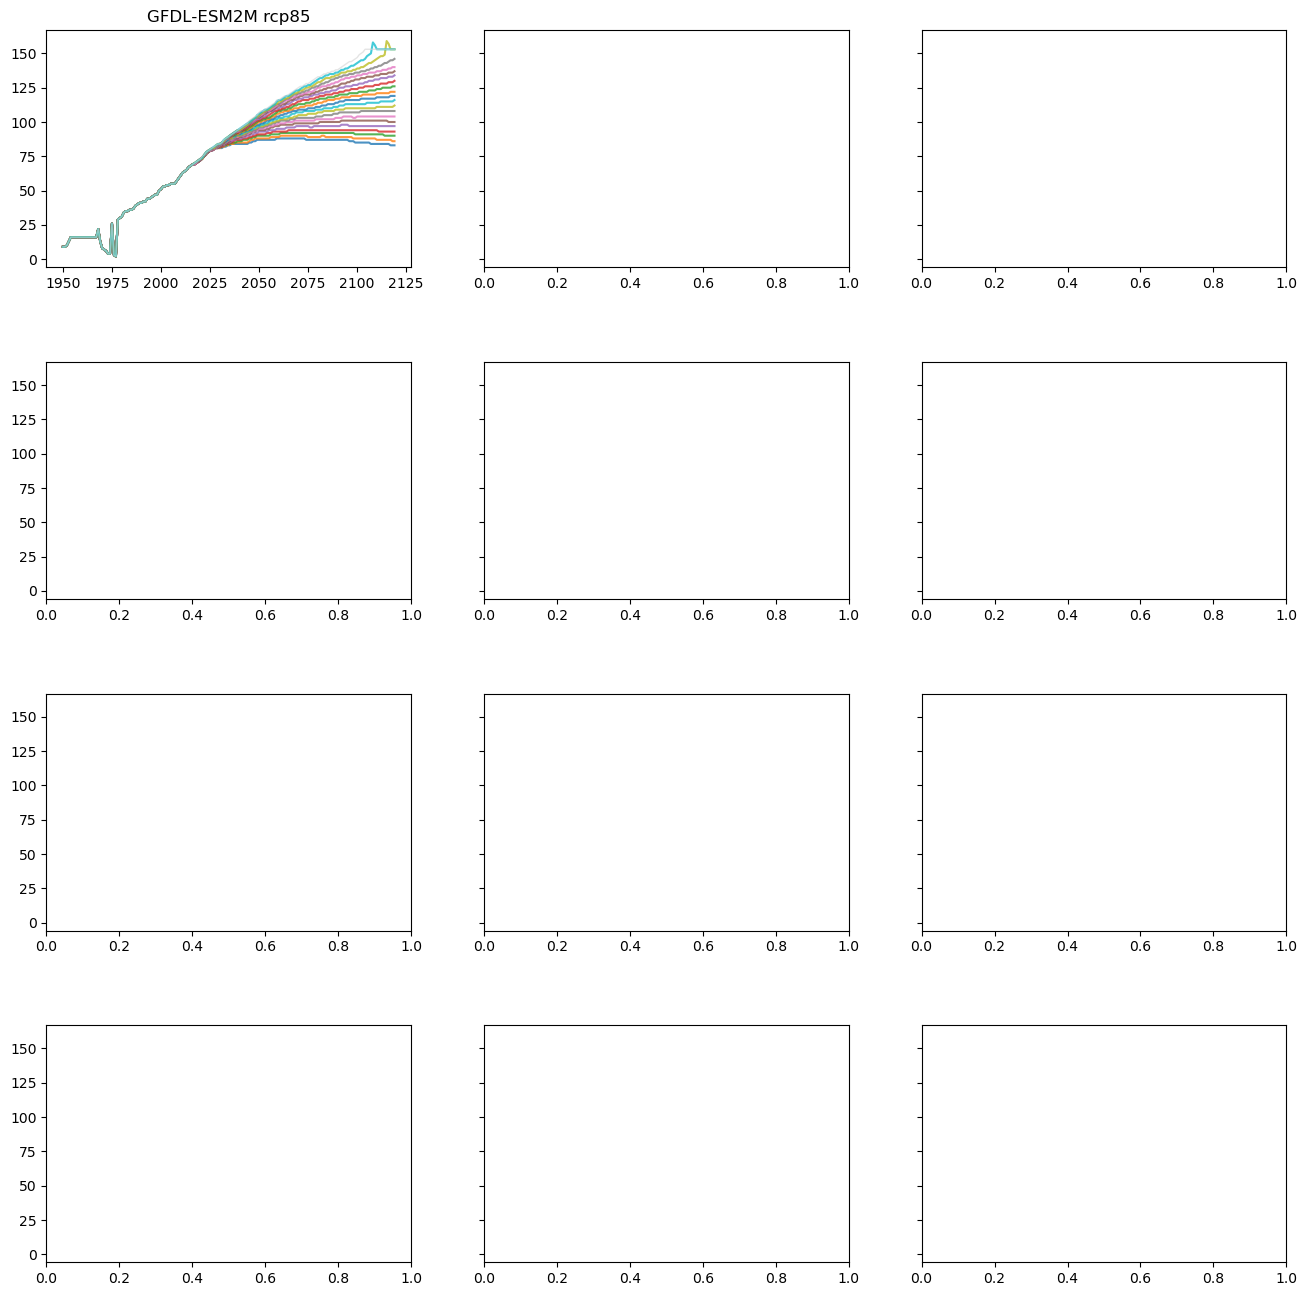

In [24]:
# PLOTTING
# Visualise the GMT trajectories that can be reconstructed using the remapping procedure.

# Instructions: 
# what is being shown on the x-axis, y-axis? Give proper title at least for the y-axis
# What does each subpanel correspond to?
# What does each line correspond to? 
# Why are some grey and some coloured? Why do those panels to the right have more coloured lines and those to the left less? 
# Where do the differences between the rows come from?
# Save this plot.
# How would these results differ if we looked at another extreme indicator?

fig, axes = plt.subplots(4,3,figsize=(16,16),sharey=True)  # Adjust to correct expected number of subpanels
axes=axes.flatten()

# Adjust the space between rows
plt.subplots_adjust(hspace=0.4)

# Collect all unique GMT levels (column names) for the legend
all_gmt_levels = df_GMT_strj.columns

# Create a list of proxy artists for the legend
legend_elements = [
    Line2D([0], [0], color='C{}'.format(i % 10), lw=1.5, alpha=0.8, label=level)
    for i, level in enumerate(all_gmt_levels)
]

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['gcm']+' '+d_climate_data_meta[i]['scenario'])

# Add the legend to the entire figure (outside all subplots)
fig.legend(handles=legend_elements, loc='lower center', ncol=len(all_gmt_levels)//2, bbox_to_anchor=(0.5, 0.02))

## 5) Land fraction exposed

This section actually transforms the values simulated by the ISIMIP models into projections of exposure to the selected indicator for the GMT trajectories of interest in this analysis.
It loads the simulations of interest and applies the indices previously calculated for the GMT mapping recipe.

In [25]:
### Instructions: To which GCM and scenario experiment does each entry correspond to?


In [26]:
# Run the function to calculate land fraction exposed to extrem events. Make sure to load the correct dictionary with metadata on the target GMT trajectories and their corresponding mapping recipes.

ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    wrong_dict_w_metadata, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_indiaws,
    weights=None,
    areaweighted=True,
    convert_to_binary=False,            # if your data array is number of exceedances per year (not binary) you will get area-weighted average number of exceedances by default
                                        # if you set this to True your data is turned binary and you can get fraction of land area exposed to at least 1 day
    convert_to_binary_threshold=0,      # here you can change the threshold to e.g. get the fraction of land area exposed to at least X days 
    smoothing_window=21                 # window to smooth also the impact data, get only forced signal not internal variability
                                        
)

                         🟠 Remapping Simulation 1 of 1 🟠

Loading /home/b/b383838/data_dem4cli/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /home/b/b383838/data_dem4cli/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp85_heatwavedarea_global_annual_landarea_2006_2099.nc4


sh: getfattr: command not found
sh: getfattr: command not found


load_climate_data_array took 0.40 s
Computing land fraction exposed (LFE) for RCP 

Computing land fraction exposed (LFE) for 15                

Computing land fraction exposed (LFE) for 20                

Computing land fraction exposed (LFE) for NDC               

Computing land fraction exposed (LFE) for OS                

Computing land fraction exposed (LFE) for noOS              

Computing land fraction exposed (LFE) for strj              

calc_landfraction_exposed took 195.87 s                     


In [27]:
### Instructions: What does the previous function generate?


In [28]:
# Create a dictionary of labels for the next plot

rename_dict = {
    #i: " ".join(["hadgem2-es (h-c)", "rcp60 (hc)"])
    i: f"{d_climate_data_meta[i]['gcm']} {d_climate_data_meta[i]['scenario']}"
    for i in d_climate_data_meta.keys()
}

rename_dict

{1: 'GFDL-ESM2M rcp85'}

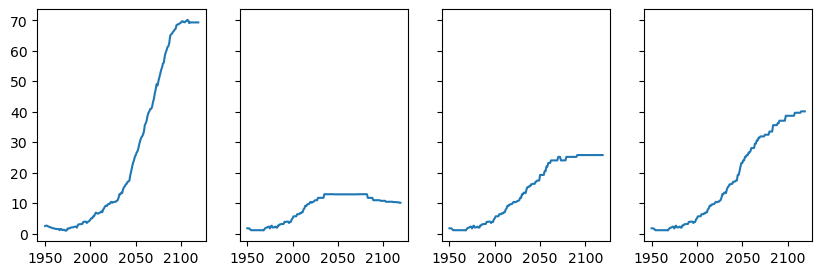

In [31]:
# PLOTTING: projections of land fraction exposed to extreme events

# Instructions:
# what is being shown on the x-axis, y-axis? 
#   --> Give proper titles at least for the y-axis

# What does each subpanel correspond to?
#   --> add title for each subpanel to reflect that
# How to interpret the differences between the subpanels?

# These plots are showing results for which countries or regions? 
#   --> Include this information in the y-axis title

# What does each line correspond to? 
#   --> Add a legend with labels for each line
# What do the differences between the lines tell us?

# Save this plot.

# Can you plot these results for a specific country?

# Later in the exercise, show and save results for at least another extreme indicator.


fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_lfe_perregion_perrun*100).sel(region=0)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0], legend=False)
(ds_lfe_perregion_perrun*100).sel(region=0)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1], legend=False)
(ds_lfe_perregion_perrun*100).sel(region=0)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2], legend=False)
(ds_lfe_perregion_perrun*100).sel(region=0)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3], legend=False)

for i,ax in enumerate(axes):
    ax.set_xticklabels([int(t + year_start) for t in ax.get_xticks()])
    ax.set_xlabel('')  # Remove the x-axis title/label for each subplot

# Adjust the figure to make room for the legend
plt.subplots_adjust(bottom=0.3)

plt.show()

## 6) Lifetime exposure 

This section actually transforms the values simulated by the ISIMIP models into projections of exposure over lifetime across birth cohorts for the GMT trajectories of interest in this analysis.
It loads the simulations of interest, applies the indices previously calculated for the GMT mapping recipe, then combines with the variables contianing the required demographic information calculated earlier in the dataset.



In [32]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, da_life_expectancy_perregion = calc_lifetime_exposure(
   d_climate_data_meta,
   df_countries, 
   countries_regions, 
   countries_mask, 
   climatedata_dir,
   da_population, 
   df_life_expectancy_5,
   da_cohort_size,
   GMT_labels=df_GMT_strj.columns , 
   GMT_extra_trajectories_names=GMT_extra_trajectories_names,
   start_birthyear=1950,
   end_birthyear=2025,
   year_start=1950,
   year_end=2119,
   bbox=bbox_indiaws,
   smoothing_window=21   
    )



                         🟠 Remapping Simulation 1 of 1 🟠

Loading /home/b/b383838/data_dem4cli/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /home/b/b383838/data_dem4cli/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_gfdl-esm2m_rcp85_heatwavedarea_global_annual_landarea_2006_2099.nc4


sh: getfattr: command not found
sh: getfattr: command not found


load_climate_data_array took 0.29 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lifetime exposure (LE) for strj 

calc_lifetime_exposure took 243.63 s


In [33]:
# Instructions: what does the previous function generate?


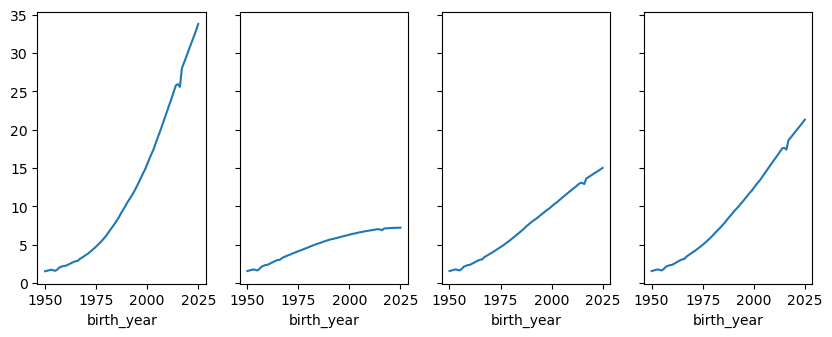

In [35]:
# PLOTTING: projections of land fraction exposed to extreme events

# Instructions:
# what is being shown on the y-axis this time?
# Is it the same x-axis as before? 
#   --> Give proper axis titles 

# What does each subpanel correspond to?
#   --> add title for each subpanel to reflect that

# These plots are showing results for which countries or regions? 
#   --> Include this information in the y-axis title

# What does each line correspond to? 
#   --> Add a legend with labels for each line
# What do the differences between the lines tell us?

# Save this plot.

# Can you plot these results for a specific country?

# Later in the exercise, show and save results for at least another extreme indicator.


fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_RCP'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[0], legend=False)
(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_15'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[1], legend=False)
(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_20'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[2], legend=False)
(ds_le_perregion_perrun.sel(region=0)['le_perregion_perrun_NDC'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[3], legend=False)

# Adjust the figure to make room for the legend
plt.subplots_adjust(bottom=0.2)

plt.show()

## 7) Compute multi-model mean and model spread

Compute the median, mean and spread across remapped / synthetic trajectories obtained from individual runs (GCM-scenario-impact model combinations).

In [36]:
#  area-weighted average land fraction exposed over regions

ds_lfe_perregion_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_perregion_perrun,
    GMT_extra_trajectories_names,
    )



Computing the MMM and stats for each region


In [37]:
# area-weighted average lifetime exposure over regions

ds_le_perregion_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


In [38]:
#  area-weighted average land fraction exposed over countries

ds_lfe_percountry_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_percountry_perrun,
    GMT_extra_trajectories_names,
    )


Computing the MMM and stats for each country


In [39]:
# area-weighted average lifetime exposure over countries

ds_le_percountry_mmm = calc_lifetime_exposure_mmm(
    ds_le_percountry_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each country


## 8) Plot results for the multi-model mean and the model spread

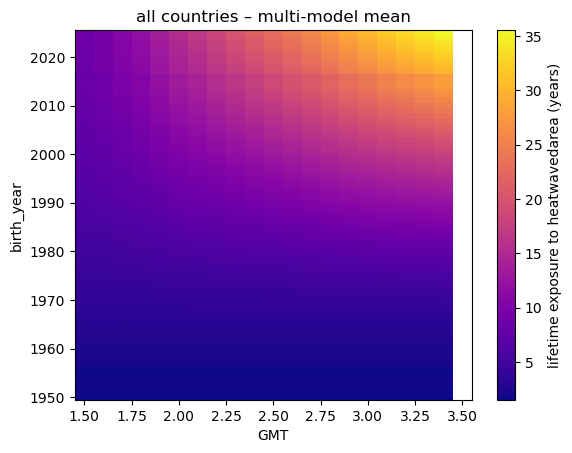

In [41]:
# PLOTTING: lifetime exposure as a heatmap, function of birth year and GMT
# This plot displays results in a similar way as Fig. 2 in Thiery et al. (2021) or Fig.3 of Grant et al. (2025).

# Instructions:
# How is the heatmap constructed? Which synthetic trajectories are used in particular for that case
# On which model is it based?
# What are the units?
# And the axes?

# Plot the same results, but this time express the lifetime exposure as a percentage of the lifetime.
# Hint: we're talking here about expected lifetime.

plot = (ds_le_perregion_mmm['median_strj']).sel(region=0).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes[0]} (years)"},
    cmap='plasma'
    )

# Get the current axes object
ax = plt.gca()

plt.title('all countries – multi-model mean')

# Show the plot
plt.show()

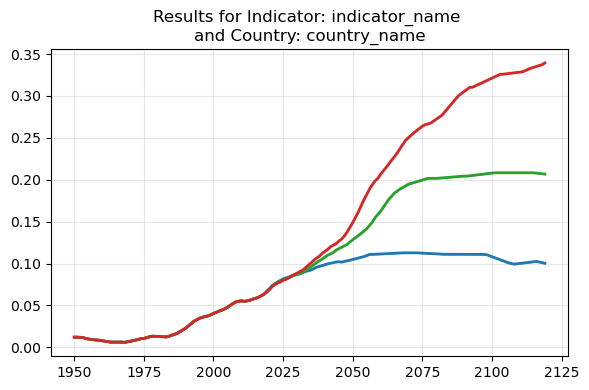

In [45]:
# PLOTTING: multi-model mean projections of land fraction exposed for various scenarios

# Instructions: 
# What variable is being shown here?
#   --> Add y-axis title
# What is the x-axis?
#   --> Add x-axis title
# For which region or country?
# What are the 3 scenarios we're looking at? Which synthetic trajectories do they correspond to?

# Reproduce and save results for other regions, countries, scenarios of interest.
# Reproduce and save results for other indicators of interest.

# === Parameters ===
country_name = 'India'  # <-- change the country here
year_range = np.arange(1950, 1950+len(ds_lfe_percountry_mmm.time_ind))

# === Define the scenarios to plot ===
GMTs = 1.5, 2, 2.4
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}

# === Create the figure ===
plt.figure(figsize=(6,4))

for i,scen in enumerate(GMTs):
    # Extract multi-model mean and standard deviation for this scenario
    mmm = ds_lfe_percountry_mmm[f'mmm_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean() 
    std = ds_lfe_percountry_mmm[f'std_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean()
    
    # Plot the mean
    plt.plot(
        year_range, 
        mmm, 
        label=f'Scenario {scen}', 
        color=colors[i],
        lw=2
    )
    
    # Plot the uncertainty range (±2σ)
    plt.fill_between(
        year_range,
        mmm - std,
        mmm + std ,
        alpha=0.3,
        label=rf'±σ',
        color=colors[i],
        lw=1
    )

# === Customize the plot ===
plt.title("Results for Indicator: indicator_name \nand Country: country_name")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


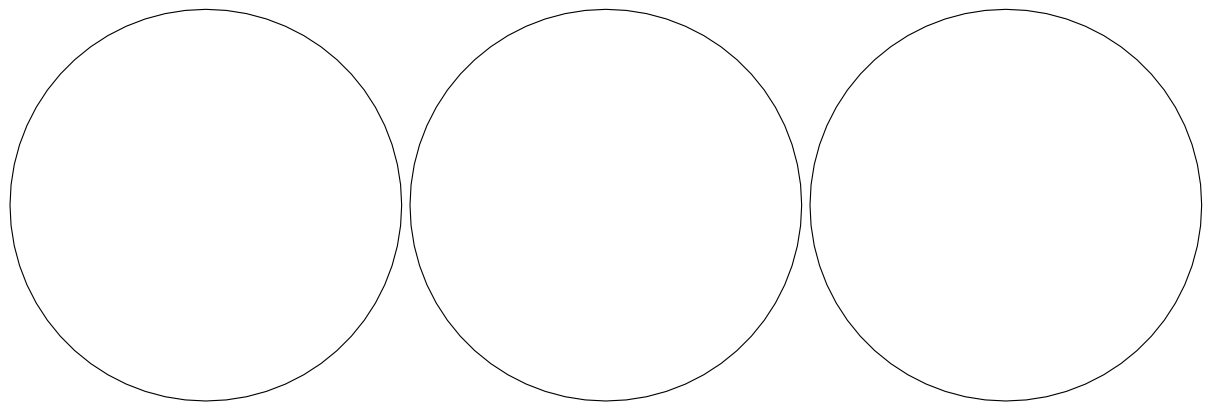

In [51]:
# PLOTTING: maps with results at the national level
# Lifetime exposure as a function of GMT level reached in 2100 and birth year
# 
# Instructions:
# What variable should be plotted here? Let's take the example of the multi-model mean to start with.
# Plot results for the GMT level reached in 2100 and birth year of your choice. 
# Each of the subpanels should show results for a different combination of GMT reached in 2100 and birth year.


# -------------------- Parameters -------------------- #
GMTs = []    # list of 3 GMT levels for 2100
birth_years = []  # list of birth cohorts
titles = ['a)', 'b)', 'c)']

use_log_scale = False

vmin=0
vmax=30

cmap = plt.cm.Oranges # or OrRd

# -------------------- Projections ---------- #

central_lon, central_lat = 83, 18.5
extent = [66, 100, 2, 40]

proj = ccrs.Orthographic(central_lon, central_lat)

# -------------------- Plot -------------------- #

fig, axes = plt.subplots(1,3, figsize=(12,8),subplot_kw={'projection': proj},  layout='constrained')


for ax, birth_year, GMT, title in zip(axes.flatten(), birth_years, GMTs, titles):


    # -------------------- Extract values from ds_le_percountry -------------------- #
    # Multi-model mean for the selected scenario
    le_mean = wrong_var_name[f'mmm_strj'].sel(birth_year=birth_year, GMT=GMT) 

    # Convert to DataFrame
    df_values = le_mean.to_dataframe(name='mean_val').reset_index()

    # -------------------- Merge with country borders -------------------- #
    gdf_plot = gdf_country_borders.reset_index().merge(
        df_values, left_on='name', right_on='country', how='left'
    )

    gdf_plot.to_crs(proj).plot(
    ax=ax,
    column='mean_val',
    cmap=cmap,
    legend=False,
    legend_kwds={'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    vmin=vmin,vmax=vmax
    )

    ax.set_extent(extent)
    gl = ax.gridlines( draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines(resolution='50m')

    print(gdf_plot['mean_val'].min(), gdf_plot['mean_val'].max())

